# 📌 Project Overview
The Cardiac Patient Monitoring System is a machine learning and deep learning project that analyzes cardiovascular health data to identify patterns associated with cardiovascular disease.

The project follows a complete data science workflow, including data cleaning, exploratory data analysis, statistical analysis, supervised learning, deep learning, hyperparameter tuning, threshold optimization, and unsupervised learning.

Multiple machine learning and deep learning techniques are applied to build predictive models, evaluate their performance, and explore the underlying patterns within the patient data.

The main objective is to develop and evaluate reliable predictive models for cardiovascular disease classification while gaining meaningful insights from demographic, clinical, and lifestyle features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
# Load the cleaned cardiovascular dataset
df = pd.read_csv("cardio_cleaned.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [3]:
# Define original features and target
X = df.drop(columns=["cardio", "id"])
y = df["cardio"]

print("Feature shape:", X.shape)
print("Features:", X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (68742, 11)
Features: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years']

Target distribution:
cardio
0    34720
1    34022
Name: count, dtype: int64


In [4]:
# First split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: 80% training, 20% validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (43994, 11)
Validation set: (10999, 11)
Test set: (13749, 11)


In [5]:
# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_final)

# Transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (43994, 11)
Scaled validation shape: (10999, 11)
Scaled test shape: (13749, 11)


## Neural Network

A neural network is trained using the original features, with no
hyperparameter tuning and no feature engineering.

In [6]:
# Build neural network
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7229 - loss: 0.5602 - val_accuracy: 0.7266 - val_loss: 0.5502
Epoch 2/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7312 - loss: 0.5483 - val_accuracy: 0.7302 - val_loss: 0.5484
Epoch 3/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7334 - loss: 0.5458 - val_accuracy: 0.7288 - val_loss: 0.5463
Epoch 4/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7331 - loss: 0.5442 - val_accuracy: 0.7294 - val_loss: 0.5481
Epoch 5/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7326 - loss: 0.5430 - val_accuracy: 0.7308 - val_loss: 0.5464
Epoch 6/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7339 - loss: 0.5425 - val_accuracy: 0.7329 - val_loss: 0.5450
Epoch 7/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7361 - loss: 0.5416 - val_accuracy: 0.7304 - val_loss: 0.5490
Epoch 8/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7345 - loss: 0.5413 - 

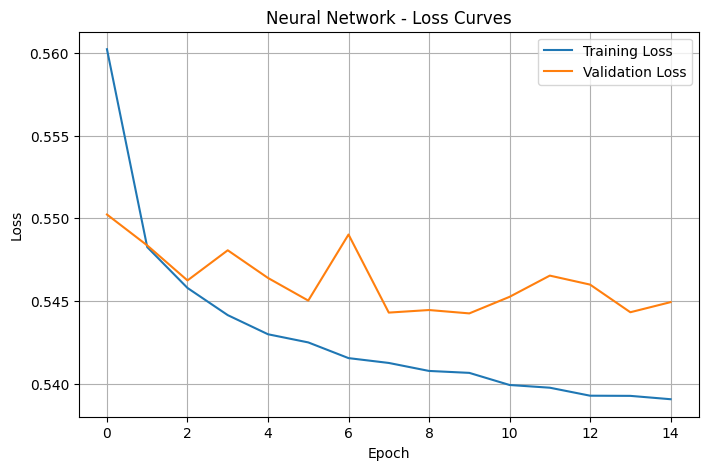

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network - Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

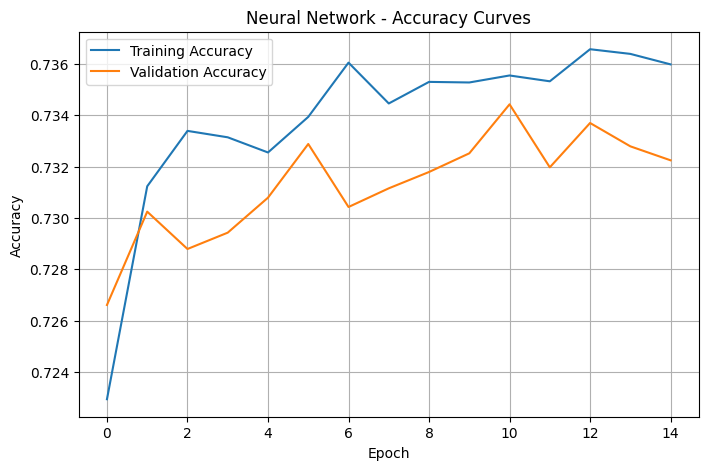

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network - Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()

##  Evaluation

The neural network is evaluated on the validation set using
Accuracy, Precision, Recall, and F1-score.

F1-score is used as the main comparison metric for the later experiments.

In [10]:
# Predict validation probabilities
y_val_prob = model.predict(
    X_val_scaled,
    verbose=0
)

# Convert probabilities to class predictions
y_val_pred = (
    y_val_prob >= 0.5
).astype(int).ravel()

# Calculate metrics
val_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

val_precision = precision_score(
    y_val,
    y_val_pred
)

val_recall = recall_score(
    y_val,
    y_val_pred
)

val_f1 = f1_score(
    y_val,
    y_val_pred
)

print("Neural Network - Validation Results")
print("-" * 48)
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")

Neural Network - Validation Results
------------------------------------------------
Accuracy : 0.7325
Precision: 0.7448
Recall   : 0.6991
F1-score : 0.7212


##  Test Set Evaluation

The model is evaluated on the same unseen test set to measure how well it
generalizes beyond the training and validation data.

In [11]:
# Evaluate the model on the unseen test set
y_test_prob = model.predict(
    X_test_scaled,
    verbose=0
)

y_test_pred = (
    y_test_prob >= 0.5
).astype(int).ravel()

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

print("Neural Network - Test Results")
print("-" * 50)
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

Neural Network - Test Results
--------------------------------------------------
Accuracy : 0.7327
Precision: 0.7440
Recall   : 0.7012
F1-score : 0.7220


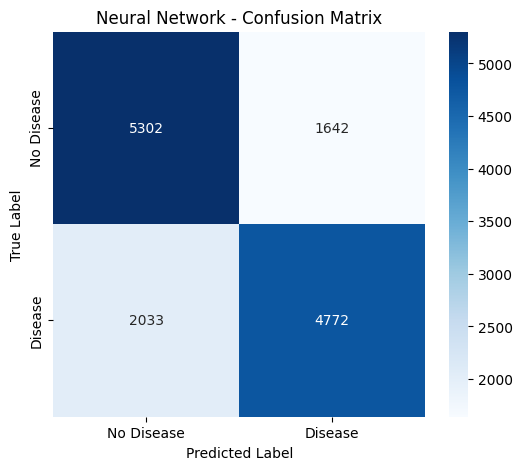

In [12]:
# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Neural Network - Confusion Matrix")

plt.show()